In [1]:
#Import libraries for generating images
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import ndimage

In [2]:
#Import libraries for saving files
import os
import subprocess

In [3]:
#Set file save place based on current directory
bas_dir = os.getcwd()

In [4]:
#Remove warning messages
np.seterr(divide='ignore', invalid='ignore', over='ignore')

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [5]:
#Define symbol for functions
z = Symbol('z')

## Parameters used:

- func - Function of variable z
- max_abs_re - Width of real axis of section
- max_abs_im - Width of imaginary axis of section
- h_range - Number of points in imaginary axis of section
- w_range - Number of points in imaginary axis of section
- centre - Centre point of section
- point_iters - Number of iterations applied to get points near basins in Python function 'iterated_points'
- newt_iters - Number of iterations applied to get attracting points in Python function 'nearby_attractors'
- infty_tol - Tolerance level for when a point is considered to have converged to infinity
- attr_tol - Tolerance level for when a point is considered to have converged to a point other than infinity
- n - n-fold iterate of function
- z_n - Array of points in Python function 'nearby_attractors'
- max_cycle_length - Maximum periodic cycle length of points in function
- attrs - Set of attracting points other than infinity, if applicable
- fatou_set - Fatou set in Python function 'plot_julia_fatou'
- colour_maps - Colour maps in Python function 'plot_julia_fatou'

## Functions used:

- iterated_points - A function to determine the k-fold iterate of points.
- iterate_func - A function to determine the n-fold iterate of a function.
- nearby_attractors - A function to determine the attracting points of a function via Newton's root-finding algorithm.
- find_attractors - A function to determine the attracting points of a function.
- basins - A function to determine the basins of attracting points.
- newton_func - A function to apply the Newton-Raphson method on a function.
- plot_julia_fatou - A function to plot the Fatou and Julia sets of a function.
- plot_julia - A function to plot the Julia set of a function, i.e. the shared boundary of the basins of a function.
- cmap - A function to create a colour map.
- colourmaps - A function to get colour maps to use for plotting.

In [6]:
def iterated_points(func, h_range = 10, w_range  = 10, max_abs_re = 1.4, max_abs_im = 1.4, centre = 0, infty_tol = 2, point_iters = 100):
    '''
    A function to determine the k-fold iterate of points.
    Takes a function,
    an array size specified by h_range and w_range, in pixels,
    the width of the real and imaginary axes for the plot,
    the centre point for the plot,
    the tolerance level for when a point is considered to have diverged to infinity,
    and the number of iterations to apply.
    Returns the k-fold iterate of points.
    '''
    #2D array of points
    y, x = np.ogrid[max_abs_im + centre.imag: -max_abs_im + centre.imag: h_range*1j, -max_abs_re + centre.real: max_abs_re + centre.real: w_range*1j]
    z_array = x + y*1j
    
    lam_func = lambdify(z, func) #Function f(z)
    diverged = np.full(z_array.shape, False) #Array of False values

    for i in range(point_iters):
        z_array[~diverged] = lam_func(z_array[~diverged]) #Iterate points through function

        #Handling diverging points
        diverged |= (np.abs(z_array) > infty_tol) #Array of Trues and Falses, depending on if a point has diverged to infinity or not

    return z_array[~diverged]

In [7]:
def iterate_func(func, n=1):
    '''
    A function to determine the n-fold iterate of a function.
    Takes a function and a value n.
    Returns the n-fold iterate of the function.
    '''
    new_func = func
    
    for i in range(2, n+1):
        new_func = new_func.subs(z, func) #Iterate function

    return new_func

In [8]:
def nearby_attractors(func, z_n, max_orbit_size = 1, infty_tol = 2, attr_tol = 1e-2, newt_iters = 10):
    '''
    A function to determine the attracting points of a function via Newton's root-finding algorithm.
    Takes a function,
    an array of points that are near attracting points,
    the maximum periodic orbit size,
    tolerance levels for when a point is considered to have diverged to infinity or converged to an attracting point,
    and the number of iterations to apply.
    Returns an array with the attracting points and a numbering of their periodic orbits.
    '''
    periodic_points = []
    periodic_orbit_nos = [] #Array of number of each periodic orbits, to distinguish different orbits from each other
    lam_func = lambdify(z, func) #Function f(z)
    z_n = z_n.reshape(-1)

    #Find size-k periodic orbits
    for k in range(1, max_orbit_size + 1):
        func_comp = iterate_func(func, k)
        func_for_roots = func_comp - z

        func_roots_diff = func_for_roots.diff(z)
        
        lam_roots_func = lambdify(z, func_for_roots) #Function f^k(z) - 1
        lam_func_roots_diff = lambdify(z, func_roots_diff) #Function f^k'(z) - 1

        z_array = z_n.copy()
        
        diverged = np.abs(z_array) > infty_tol #Initialise array of Trues and Falses, depending on if a point has diverged to infinity or not

        #Apply Newton's root finding algorithm
        for i in range(newt_iters):
            z_array[~diverged] -= lam_roots_func(z_array[~diverged]) / np.where(lam_func_roots_diff(z_array[~diverged]) == 0, 1e-9, lam_func_roots_diff(z_array[~diverged])) #np.where used to prevent division by 0

            #Handling diverged points
            diverged |= (np.abs(z_array) > infty_tol) #Update diverged array, depending on if a point has now diverged to infinity or not
        
        z_array = z_array[~diverged] #Remove diverged points from array
        
        #Make 2D array of proposed size-k periodic orbits for each point
        orbits = [z_array]
        z_orbit_array = z_array.copy()
        
        true_array = np.full(z_orbit_array.shape, True) #Used to ensure that z_orbit_array has the correct dimension when the function is a constant
        for j in range(1, k):
            z_orbit_array[true_array] = lam_func(z_orbit_array[true_array])
            #z_orbit_array = np.atleast_1d(z_orbit_array) #Ensure that this is an array (lambified function converts single element array into a number)
            orbits.append(z_orbit_array.copy())
        orbits = np.array(orbits)
        
        #Find which proposed periodic orbits are actually periodic orbits and consist of attracting points
        #Checking that each point z is finite, that |f^k'(z)|<1 and that f^k(z) ≈ z
        z_n_to_append = np.isfinite(z_array) & (np.abs(lam_func_roots_diff(z_array) + 1) < 1) & (np.abs(lam_roots_func(z_array)) < attr_tol)

        for m in range(len(z_orbit_array)):
            if z_n_to_append[m]:
                points_in_orbit = orbits[:, m]
                periodic_points.extend(points_in_orbit)
                periodic_orbit_nos.extend([m + len(z_n)*(k-1)]*k) #Append number k times
    
    #Exclude repeats of periodic orbits
    unique_attractors = []
    unique_orbit_nos = []
    for i, p in enumerate(periodic_points):
        if not np.any(np.isclose(p, unique_attractors, atol = attr_tol)): #First instance of this element of some periodic orbit
            unique_attractors.append(p)
            unique_orbit_nos.append(periodic_orbit_nos[i])
    
    #Relabel orbit numbers so they're consecutive integers (e.g. [1,2,2,3,3] rather than [1,10,10,20,20])
    next_no = 1
    consec_orbit_nos = np.array([])
    for i, entry in enumerate(unique_orbit_nos):
        if i == 0:
            consec_orbit_nos = np.append(consec_orbit_nos, [next_no])
        elif entry > unique_orbit_nos[i-1]:
            next_no += 1
            consec_orbit_nos = np.append(consec_orbit_nos, [next_no])
        else:
            consec_orbit_nos = np.append(consec_orbit_nos, [next_no])

    return unique_attractors, consec_orbit_nos

In [9]:
def find_attractors(func, h_range = 10, w_range  = 10, max_abs_re = 1.4, max_abs_im = 1.4, centre = 0, infty_tol = 2, attr_tol = 1e-2, point_iters = 100, newt_iters = 10, max_orbit_size = 1,):
    '''
    A function to determine the attracting points of a function.
    Applies the function 'iterated_points', and applies the produced array to the function 'nearby_attractors'.
    Returns an array with the attracting points and a numbering of their periodic orbits.
    '''
    near_attrs = iterated_points(func, h_range = h_range, w_range = w_range, max_abs_re = max_abs_re, max_abs_im = max_abs_im, centre = centre, infty_tol = infty_tol, point_iters = point_iters)
    
    return nearby_attractors(func, z_n = near_attrs, max_orbit_size = max_orbit_size, infty_tol = infty_tol, attr_tol = attr_tol, newt_iters = newt_iters)

In [10]:
def basins(func, h_range = 2000, w_range  = 2000, max_abs_re = 1.4, max_abs_im = 1.4, centre = 0, infty_tol = 2, attr_tol = 0.01, max_iters = 200, max_orbit_size = 1, attrs = None):
    '''
    A function to determine the basins of attracting points.
    Takes a function,
    an array size specified by h_range and w_range, in pixels,
    the width of the real and imaginary axes for the plot,
    the centre point for the plot,
    tolerance levels for when a point is considered to have diverged to infinity or converged to some attracting point,
    the number of maximum iterations to try,
    and variables for finding an array with the attracting points and a numbering of their periodic orbits if the array is unknown, or taking this array if it is known.
    Returns an array with the number of the last non-convergent iteration for each point, what attracting point each point converged to, the number of attracting points, including infinity, and whether any points diverged to infinity.
    '''
    #2D array of points
    y, x = np.ogrid[max_abs_im + centre.imag: -max_abs_im + centre.imag: h_range*1j, -max_abs_re + centre.real: max_abs_re + centre.real: w_range*1j]
    z_array = x + y*1j

    #Find attracting points if not already found
    attrs_and_orbit_nos = find_attractors(func, max_abs_re = max_abs_re, max_abs_im = max_abs_im, centre = centre, max_orbit_size = max_orbit_size, infty_tol = infty_tol, attr_tol = attr_tol) if (attrs is None) else attrs
    attrs = attrs_and_orbit_nos[0]
    orbit_nos = attrs_and_orbit_nos[1]
    attr_array = np.array(attrs).reshape(-1, 1, 1) #Convert attracting points into 3D array for calculations
    
    lam_func = lambdify(z, func)
    iterations_until_convergence = np.full(z_array.shape, max_iters) #Entries are max_iters if points doesn't converge
    converged = np.full(z_array.shape, False) #Array of False values
    diverged = np.full(z_array.shape, False) #Array of False values
    converged_to_orb = np.full(z_array.shape, -1) #Entries are -1 if points doesn't converge
    conv_or_div = np.full(z_array.shape, False) #Array of False values

    for i in range(max_iters): 
        z_array[~conv_or_div] = lam_func(z_array[~conv_or_div])
        z_attr_dist = np.abs(z_array.reshape(1, h_range, w_range) - attr_array) #Use broadcasting for element-wise subtraction with each attracting point, then take absolute values
        
        converged |= np.any(z_attr_dist < attr_tol, axis = 0) #Array of Trues and Falses, depending on if a point has converged to an attracting point or not
        diverged |= (np.abs(z_array) > infty_tol) #Array of Trues and Falses, depending on if a point has diverged to infinity or not
        
        converging_now = converged & (iterations_until_convergence == max_iters) #Array of Trues and Falses, depending on if a point has just converged to an attracting point or not
        diverging_now = diverged & (iterations_until_convergence == max_iters)
        iterations_until_convergence[converging_now | diverging_now] = i #Setting number of iterations for points that have just converged to an attracting point or diverged to infinity

        if np.any(converging_now):
            converged_to_orb[converging_now] = np.argmin(z_attr_dist[:, converging_now], axis=0) + 1 #Array of which attracting point each point converged to (to update to the orbits later)
        converged_to_orb[diverging_now] = 0

        conv_or_div |= converging_now | diverging_now
        if np.all(conv_or_div): #All points have converged to an attracting point or diverged to infinity
            break

    #Form array of which periodic orbit each point converged to
    if len(attrs) > 0:
        update = ~np.isin(converged_to_orb, [-1, 0])
        converged_to_orb[update] = orbit_nos[converged_to_orb[update] - 1] #Array of which periodic orbit each point converged to

    converged_points = ~np.isin(converged_to_orb, [-1]) #Points that converged somewhere
    some_points_div = np.any(np.isin(converged_to_orb, [0])) #Check if any points diverge to infinity
    
    return iterations_until_convergence, converged_to_orb, len(np.unique(converged_to_orb[converged_points])), some_points_div

In [11]:
def newton_func(func):
    '''
    A function to apply the Newton-Raphson method on a function.
    Takes a function of z.
    Returns the function with the Newton-Raphson method applied.
    '''
    new_func = func
    
    func_diff = new_func.diff(z)
    new_func = z - new_func / (func_diff)
        
    return new_func

In [12]:
def cmap(hue_start, hue_shift = 0.05):
    '''
    A function to create a colour map.
    Takes a starting hue number and a number corresponding to how much the hue shifts in the colour map.
    Returns a colour map.
    '''
    colours = [
        mcolors.hsv_to_rgb([(hue_start) % 1, 0.15, 1]), #light
        mcolors.hsv_to_rgb([(hue_start + hue_shift/4) % 1, 0.42, 1]), #mid-light
        mcolors.hsv_to_rgb([(hue_start + 2*hue_shift/4) % 1, 0.67, 0.99]), #mid
        mcolors.hsv_to_rgb([(hue_start + 3*hue_shift/4) % 1, 0.98, 0.73]), #mid-dark
        mcolors.hsv_to_rgb([(hue_start + hue_shift) % 1, 1, 0.28]) #dark
    ]

    return mcolors.LinearSegmentedColormap.from_list(name = f'{hue_start}', colors = colours)

In [13]:
def colourmaps(no_of_orbs, initial_hue = 0.569444, hue_shift = 0.011111):
    '''
    A function to produce an array of colour maps for a plot of the Fatou and Julia sets.
    Takes the number of attracting periodic orbits in the function,
    the initial hue for the colour map,
    and the hue shift in each colour map.
    Returns an array of colour maps.
    '''
    n = no_of_orbs
    return [cmap((initial_hue + i / n) % 1, hue_shift) for i in range(n)]

In [14]:
def plot_julia_fatou(fatou_set, colour_maps, max_abs_re = 1.4, max_abs_im = 1.4, centre = 0, max_iters = 200, save = False, subfolder = None, filename = 'plot', fmt = 'png'):
    '''
    A function to plot the Fatou and Julia sets of a function.
    Takes an array with the number of the last non-convergent iteration for each point, what attracting point each point converged to, and the number of attracting points, including infinity,
    an array of colour maps,
    the width of the real and imaginary axes,
    the centre point,
    the maximum number of iterations used when getting the basins,
    and whether to save the produced image and related parameters.
    Returns a plot of the Fatou and Julia sets.
    '''
    fig, ax = plt.subplots(figsize=(2000/300, 2000/300), dpi=300) #Initialise figure
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    layer = fatou_set[0] #Layer of the number of the last non-convergent iteration for each point
    
    no_infty = 0 if fatou_set[3] else 1 #Have colour for infinity if points diverge there
    for i in range(fatou_set[2]):
        not_converged_here = fatou_set[1] != i + no_infty #Only including points that converge to the specific attracting point (including infinity)
        mask = np.ma.masked_where((layer >= max_iters) | (not_converged_here), layer)
        ax.imshow(mask, cmap = colour_maps[i % len(colour_maps)],
                  extent = [-max_abs_re + centre.real, max_abs_re + centre.real, -max_abs_im + centre.imag, max_abs_im + centre.imag], #Area for plot
                  norm = mcolors.LogNorm(vmin = 1, vmax = max_iters, clip = True)) #Normalise values (makes colours of resulting image look better)

    ax.axis('off') #Remove axis labels
    if save:
        save_figure(fig, subfolder = subfolder, filename = filename, fmt = fmt)
    plt.show()
    plt.close(fig)

In [21]:
def plot_julia(fatou_set, max_abs_re = 1.4, max_abs_im = 1.4, centre = 0, save = False, subfolder = None, filename = 'plot', fmt = 'png'):
    '''
    A function to plot the Julia set of a function, i.e. the shared boundary of the basins of a function.
    Takes an array with the details of the basins corresponding to a function,
    the width of the real and imaginary axes,
    and the centre point.
    Returns a plot of the Julia set.
    '''
    fig, ax = plt.subplots(figsize=(2000/300, 2000/300), dpi=300)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    thickness = 1
    
    #Erode basins to find their boundaries
    boundary = np.full(fatou_set[1].shape, False) #Array of False values
    for i in range(fatou_set[2]):
        basin_mask = (fatou_set[1] == i) #Array of Trues and Falses depending on if each point converged to the specified attractor
        eroded = ndimage.binary_erosion(basin_mask, iterations = thickness)
        boundary |= (basin_mask & ~eroded) #Append points on boundary of specified attractor
    
    #Remove border points
    boundary[:thickness, :] = False
    boundary[-thickness:, :] = False
    boundary[:, :thickness] = False
    boundary[:, -thickness:] = False
    
    #Colour non-boundary and boundary points
    boundary_rgba = np.zeros((*boundary.shape, 4)) #Initialise transparent points
    boundary_rgba[boundary] = [0, 0, 0, 1] #Make boundary points be black

    ax.imshow(boundary_rgba, extent=[-max_abs_re + centre.real, max_abs_re + centre.real, -max_abs_im + centre.imag, max_abs_im + centre.imag])
    
    ax.axis('off') #Remove axis labels
    if save:
        save_figure(fig, subfolder = subfolder, filename = filename, fmt = fmt)
    plt.show()
    plt.close(fig)

In [16]:
def save_figure(fig, subfolder = None, filename = 'plot', fmt = 'png'):
    if isinstance(subfolder, str):
        os.makedirs(subfolder, exist_ok=True)
        file_path = os.path.join(subfolder, f'{filename}.{fmt}')
    else:
        file_path = os.path.join(f'{filename}.{fmt}')
        
    fig.savefig(file_path, dpi = 300, pad_inches = 0, transparent = True)

## Examples

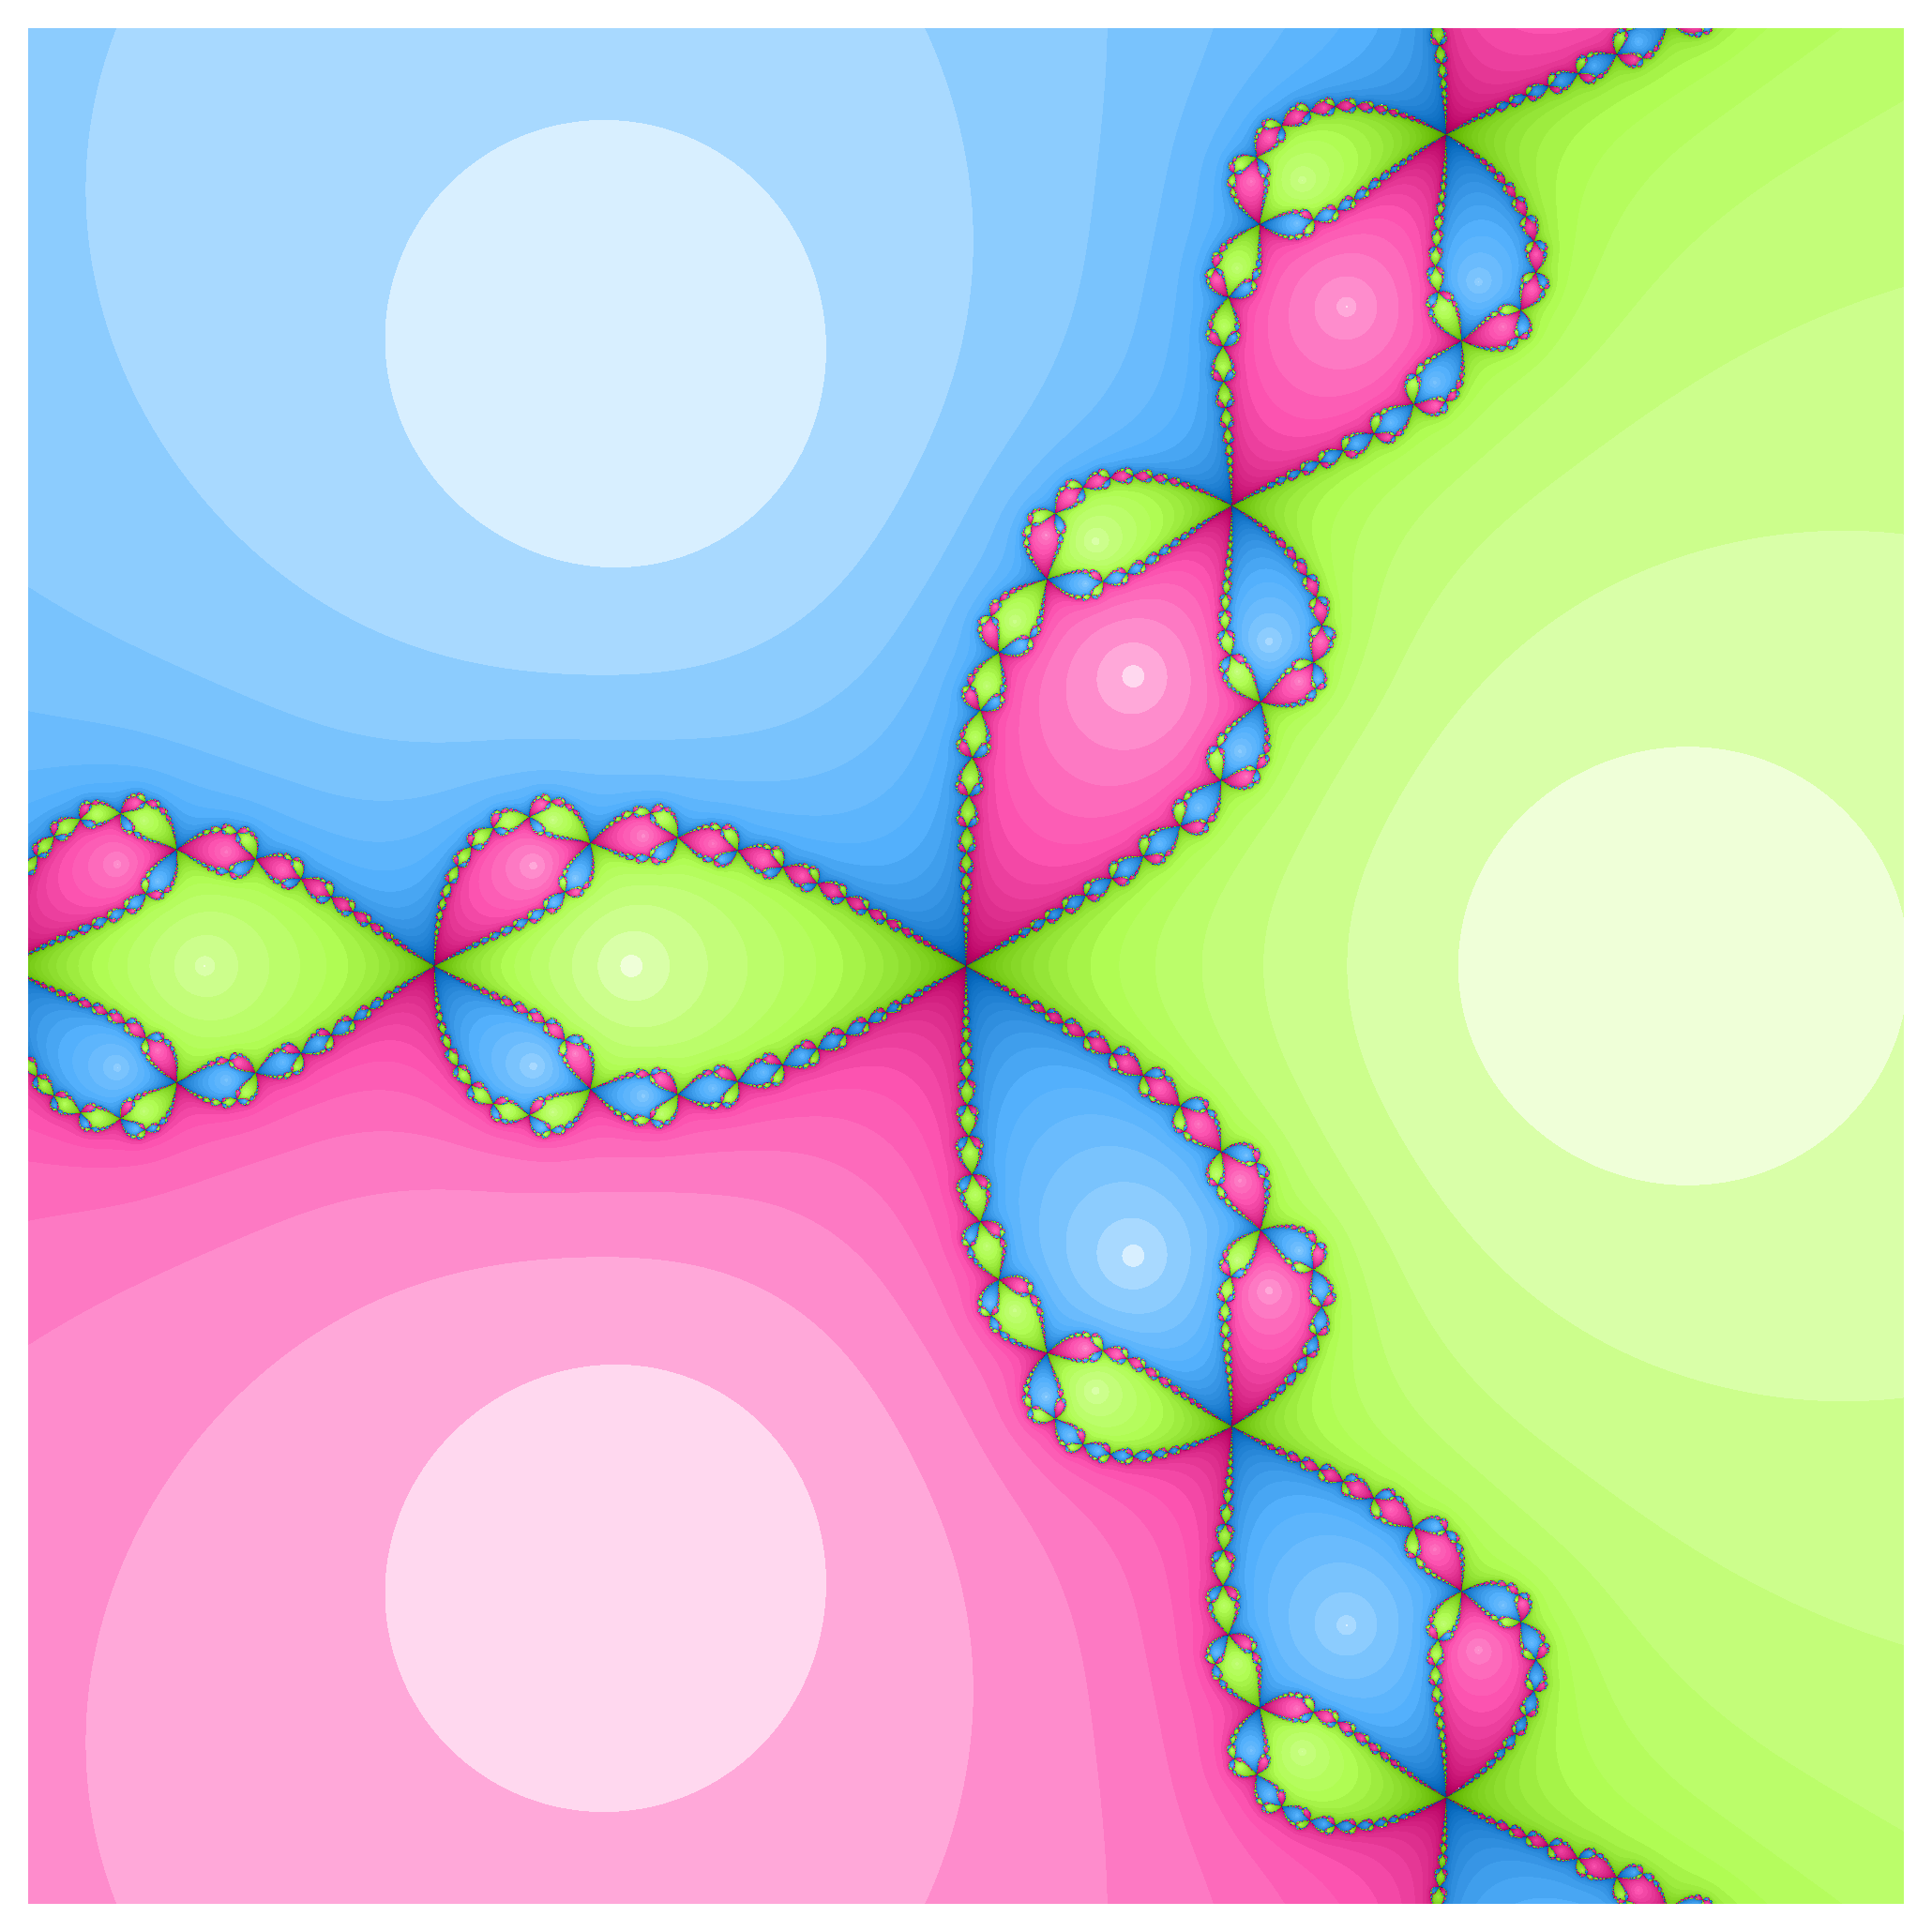

In [17]:
z = Symbol('z')
func = newton_func(z**3-1)
max_iters0 = 50
max_cycle_length0 = 2
infty_sens0 = 1e25
attr_sens0 = 1e-2
first_hue0 = 0.569444
hue_shift0 = 0.011111

attractors = find_attractors(func, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

fatou_set = basins(func, h_range = 2000, w_range = 2000, max_iters = max_iters0, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

colour_maps = colourmaps(no_of_orbs = fatou_set[2], initial_hue = first_hue0, hue_shift = hue_shift0)

plot_julia_fatou(fatou_set, colour_maps, max_iters = max_iters0)

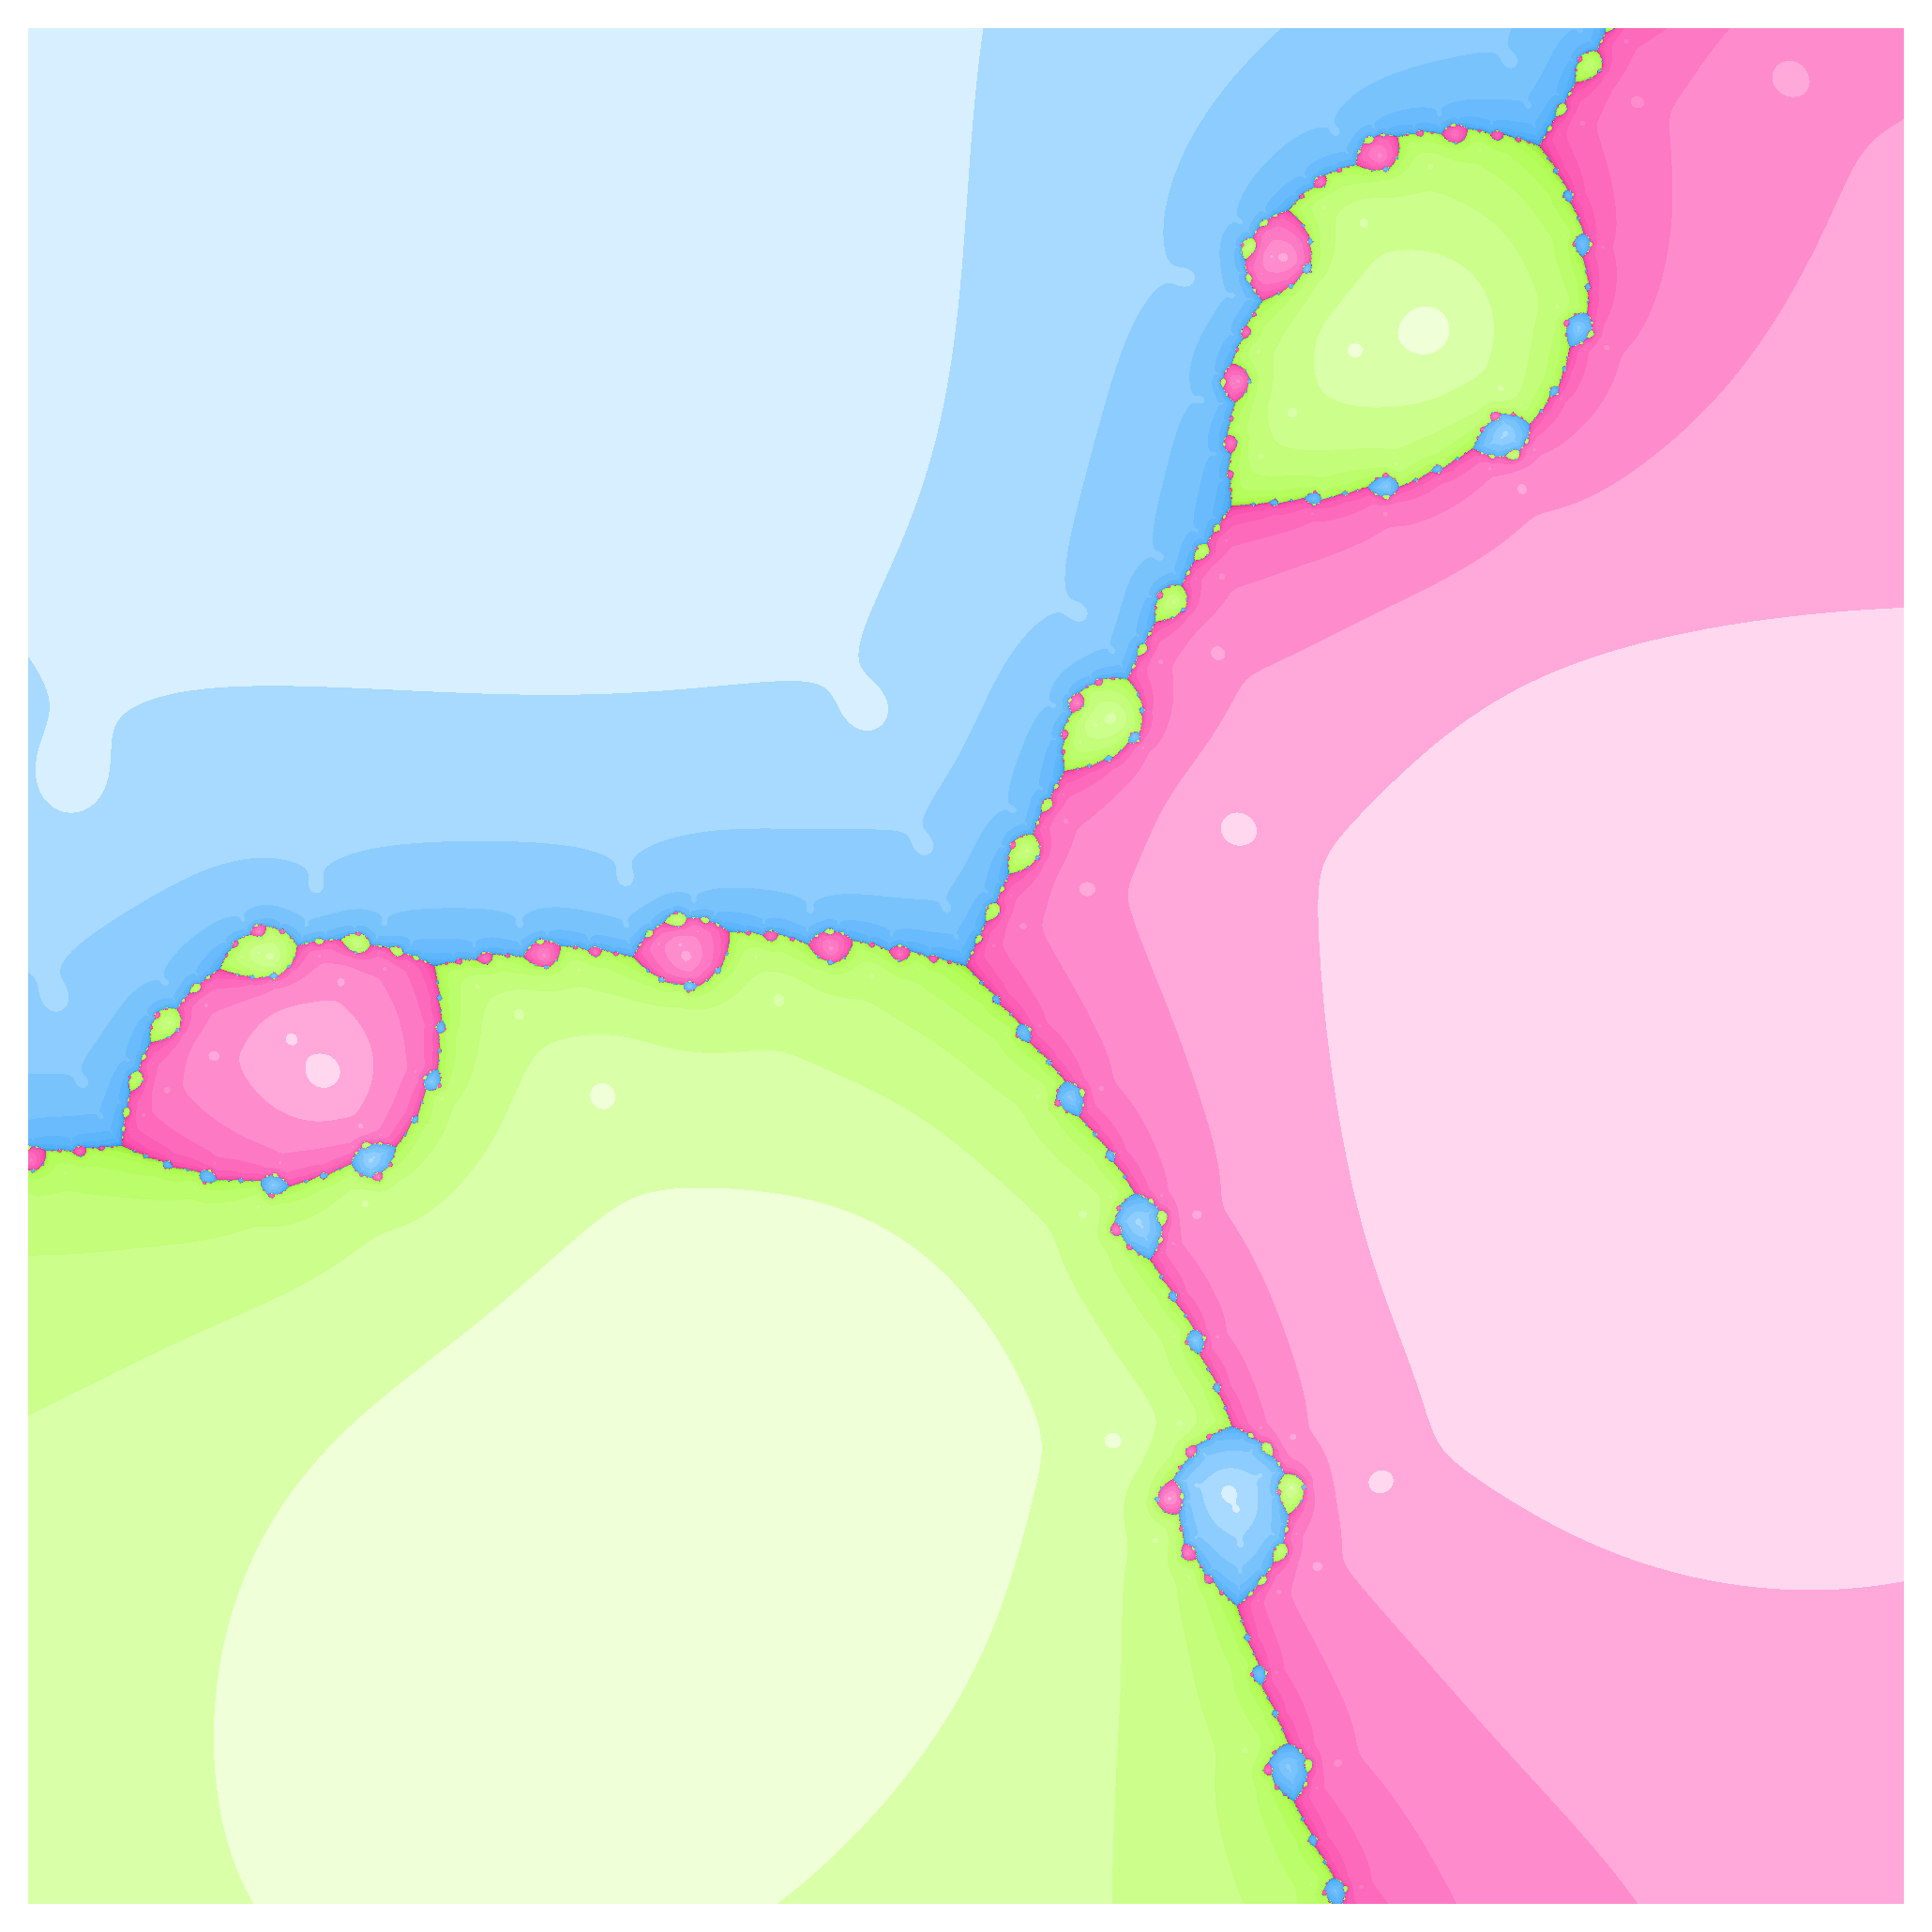

In [18]:
z = Symbol('z')
func = (z**4 + 2*z - 1j*z**2)/(2*z**3 + 1) #equal to newton_func(z**2 - 1/z + 1j)
max_iters0 = 50
max_cycle_length0 = 2
infty_sens0 = 1e25
attr_sens0 = 1e-2
first_hue0 = 0.569444
hue_shift0 = 0.011111

attractors = find_attractors(func, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

fatou_set = basins(func, h_range = 2000, w_range = 2000, max_iters = max_iters0, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

colour_maps = colourmaps(no_of_orbs = fatou_set[2], initial_hue = first_hue0, hue_shift = hue_shift0)

plot_julia_fatou(fatou_set, colour_maps, max_iters = max_iters0)

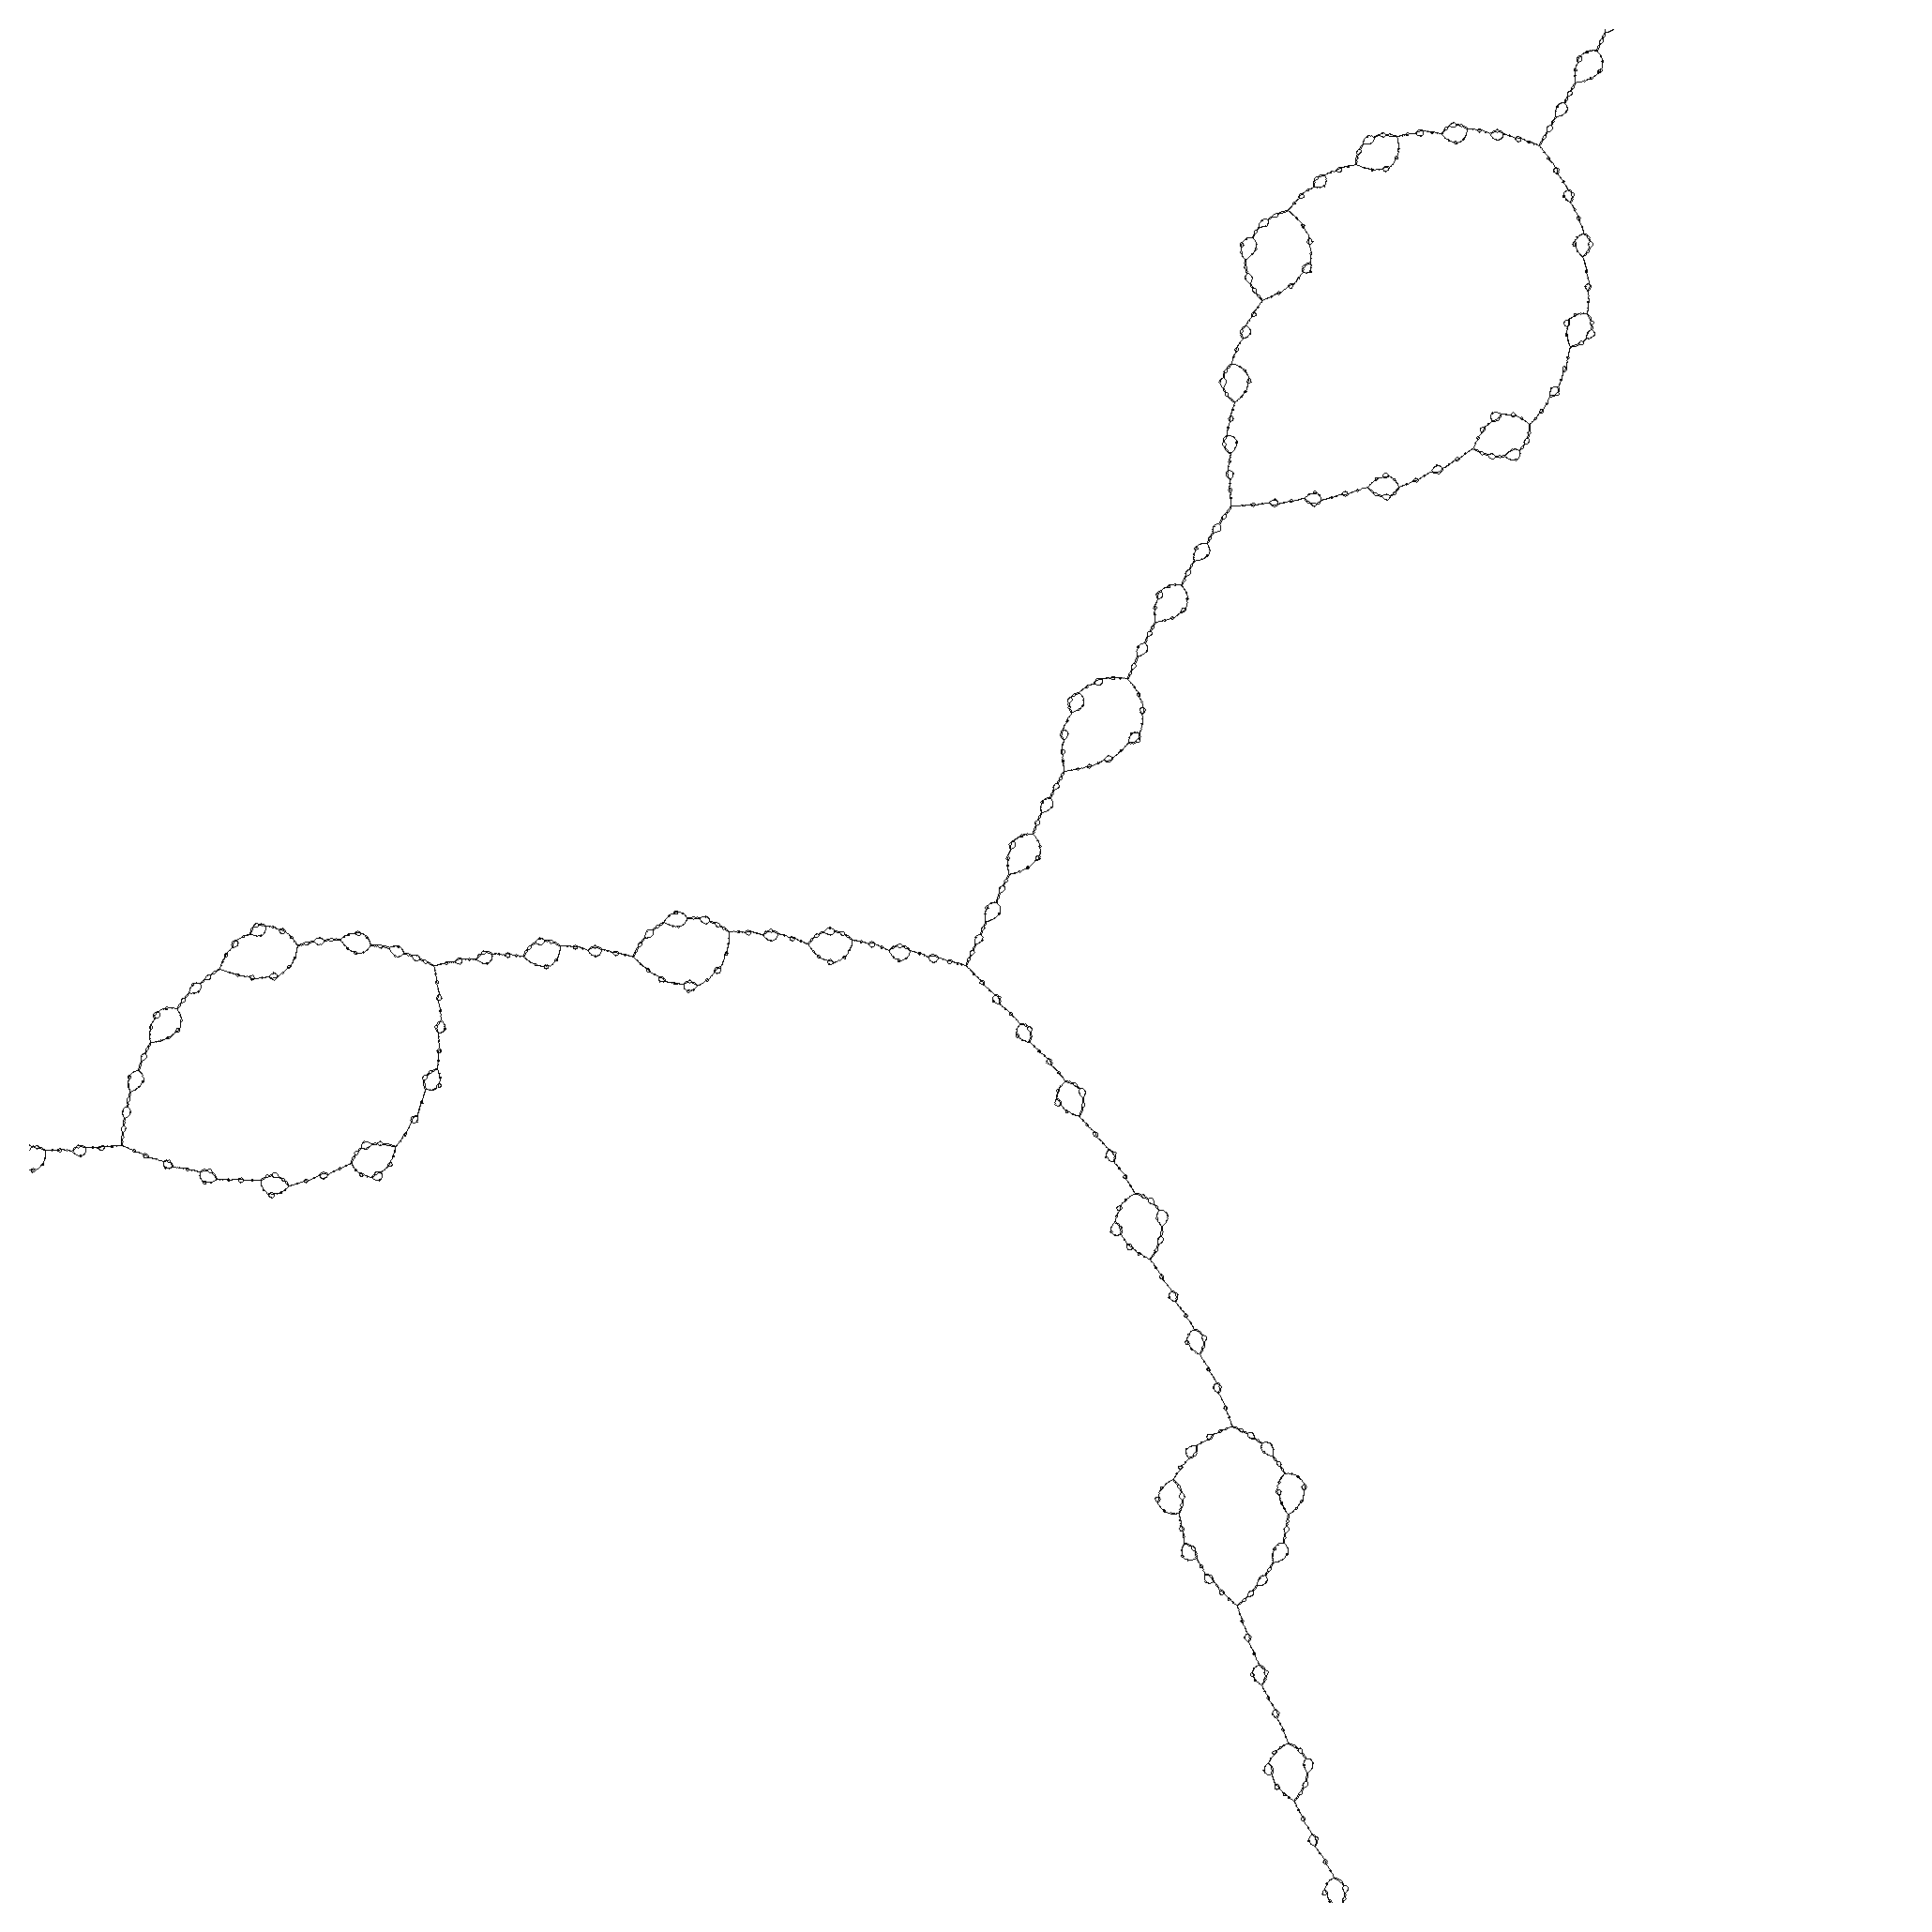

In [22]:
z = Symbol('z')
func = (z**4 + 2*z - 1j*z**2)/(2*z**3 + 1) #equal to newton_func(z**2 - 1/z + 1j)
max_iters0 = 50
max_cycle_length0 = 2
infty_sens0 = 1e25
attr_sens0 = 1e-2
first_hue0 = 0.569444
hue_shift0 = 0.011111

attractors = find_attractors(func, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

fatou_set = basins(func, h_range = 2000, w_range = 2000, max_iters = max_iters0, max_orbit_size = max_cycle_length0, infty_tol = infty_sens0, attr_tol = attr_sens0)

colour_maps = colourmaps(no_of_orbs = fatou_set[2], initial_hue = first_hue0, hue_shift = hue_shift0)

plot_julia(fatou_set)